In [1]:
#===============================================
#IMPORTING REQUIRED LIBRARIES
# ===============================================
import pandas as pd                                                 #
import numpy as np
import warnings

#Ignoring warnings to keep this notebook clean

warnings.filterwarnings('ignore')


#====================================================
#DATA VISUALIZATION LIBRARY 
# ====================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams['figure.figsize'] =(10, 5)
import plotly.express as px                                          #For interactive charts

#=======================================================
#MACHINE LEARNING LIBRARY
# ======================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error



## Data Loading
In this section, we load all required datasets for the project.

##### Datasets Included:
-**Train Data**  -> Historical Sales Data  
-**Test Data**  -> Data for predictions  
-**Stores Data**  -> Store-level information  
-**Oil Data**  -> External Economic factor  
-**Holidays & Events**  -> Seasonal effects  
-**Transactions**  -> Store activity level



In [2]:
#==========================================================================
#Loading Various Datasets
#==========================================================================
train = pd.read_csv("data/train.csv", parse_dates = ['date'])
test = pd.read_csv("data/test.csv", parse_dates = ['date'])
oil = pd.read_csv("data/oil.csv", parse_dates = ['date'])
store = pd.read_csv("data/stores.csv")
holidays =pd.read_csv("data/holidays_events.csv", parse_dates = ['date'])
transactions = pd.read_csv("data/transactions.csv", parse_dates = ['date'])

print("Datasets are Loaded Successfully")



Datasets are Loaded Successfully


## Data Merging
Here, we combine multiple datasets into a single dataframe
- We merge 'train' with 'store' using 'store_nbr'
- Then merge oil data using 'date'
- Finally, merge holidays to capture seasonal effects

This creates a unified dataset for analysis and modeling.

In [3]:
# Merging the data into dataframe
df = train.merge(store, on = "store_nbr", how ="left")
df = df.merge(oil, on = "date", how = "left")
df = df.merge(holidays, on = "date", how = "left")

### Log Transformation
The sales variable is highly skewed. A log transformation is applied to stabilize variance and improve model performance.

In [4]:
df['sales_log'] = np.log1p(df['sales'])

- We will reverse this transformation after prediction using expm1.

In [5]:
#checking on the first 10 rows to understand the structure
print(df.head(10))

   id       date  store_nbr        family  sales  onpromotion   city  \
0   0 2013-01-01          1    AUTOMOTIVE    0.0            0  Quito   
1   1 2013-01-01          1     BABY CARE    0.0            0  Quito   
2   2 2013-01-01          1        BEAUTY    0.0            0  Quito   
3   3 2013-01-01          1     BEVERAGES    0.0            0  Quito   
4   4 2013-01-01          1         BOOKS    0.0            0  Quito   
5   5 2013-01-01          1  BREAD/BAKERY    0.0            0  Quito   
6   6 2013-01-01          1   CELEBRATION    0.0            0  Quito   
7   7 2013-01-01          1      CLEANING    0.0            0  Quito   
8   8 2013-01-01          1         DAIRY    0.0            0  Quito   
9   9 2013-01-01          1          DELI    0.0            0  Quito   

       state type_x  cluster  dcoilwtico   type_y    locale locale_name  \
0  Pichincha      D       13         NaN  Holiday  National     Ecuador   
1  Pichincha      D       13         NaN  Holiday  Nation

In [6]:
print(store.columns)

Index(['store_nbr', 'city', 'state', 'type', 'cluster'], dtype='object')


In [7]:
#checking on the missing values(NaN) values are in each column
df.isnull().sum()

id                   0
date                 0
store_nbr            0
family               0
sales                0
onpromotion          0
city                 0
state                0
type_x               0
cluster              0
dcoilwtico      955152
type_y         2551824
locale         2551824
locale_name    2551824
description    2551824
transferred    2551824
sales_log            0
dtype: int64

In [8]:
#info of the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3054348 entries, 0 to 3054347
Data columns (total 17 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
 6   city         object        
 7   state        object        
 8   type_x       object        
 9   cluster      int64         
 10  dcoilwtico   float64       
 11  type_y       object        
 12  locale       object        
 13  locale_name  object        
 14  description  object        
 15  transferred  object        
 16  sales_log    float64       
dtypes: datetime64[ns](1), float64(3), int64(4), object(9)
memory usage: 396.1+ MB
None


In [9]:
df.rename(columns={
    'type_x': 'store_type',
    'type_y': 'holiday_type',
}, inplace=True)
    

In [10]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'store_type', 'cluster', 'dcoilwtico', 'holiday_type',
       'locale', 'locale_name', 'description', 'transferred', 'sales_log'],
      dtype='object')

### ## 2. Data Cleaning

### 2.1 Oil Price Imputation (`dcoilwtico`)
Oil prices are missing on weekends and holidays due to market closures. 
 To maintain continuity in the time series, missing values are filled using forward fill(ffill) followed by backward fill(bfill)
* **Goal:** This ensures the model receives a complete dataset without introducing unrealistic jumps in oil prices. 


In [11]:
df['dcoilwtico'] = df['dcoilwtico'].ffill().bfill()

#Verify the fix
print(df['dcoilwtico'].isnull().sum())

0


### 2.2 Holiday & Categorical Data
Missing values in holiday-related columns represent standard "Work Days."
* **Action:** Missing values in holiday_related columns represent non-holiday days and were filled with appropriate labels such as 'No Holiday' and 'No Event'.


In [12]:
#list of holiday columnns to fix
#===================================================================
holiday_cols = ['holiday_type', 'locale', 'locale_name', 'description', 'transferred']

#Fix:Replace columns with 'None' or 'Normal'
#===============================================================
for col in holiday_cols:
    df[col] = df[col].fillna('None')

#specific fixes
df['holiday_type'] = df['holiday_type'].replace('None', 'No Holiday')
df['description'] = df['description'].replace('None', 'No Event')
df['transferred'] = df['transferred'].fillna('False')

# Final Verification
#================================================================
print(df.isnull().sum())


id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
city            0
state           0
store_type      0
cluster         0
dcoilwtico      0
holiday_type    0
locale          0
locale_name     0
description     0
transferred     0
sales_log       0
dtype: int64


## 📅 Time-Based Features

We extract useful components from the date column to capture temporal patterns in sales.

- Year → captures Long-term trends  
- Month →  captures Seasonality  
- Day →  captures daily variation  
- Day of Week → captures Weekly patterns  

---

## 📌 Additional Features

- **Weekend Indicator**: Identifies weekends when customer behavior may differ  
- **Holiday Indicator**: Captures the impact of holidays on sales  

These features help the model better understand variations in sales over time.

In [13]:
def create_time_features(df):
    df['date'] = pd.to_datetime(df['date'])

#Time-based features
    df['month'] = df['date'].dt.month
    df['dayofweek'] = df['date'].dt.dayofweek
    df['day'] = df['date'].dt.day
    df['year'] =df ['date'].dt.year

#Flags
    df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
    df['is_holiday'] = (df['holiday_type'] != 'No Holiday').astype(int)
    return df
df = create_time_features(df)

In [14]:
print(df.columns)

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'store_type', 'cluster', 'dcoilwtico', 'holiday_type',
       'locale', 'locale_name', 'description', 'transferred', 'sales_log',
       'month', 'dayofweek', 'day', 'year', 'is_weekend', 'is_holiday'],
      dtype='object')


# 📊 Exploratory Data Analysis (EDA)

This section explores patterns, trends, and relationships in the dataset to gain insights and guide modeling decisions.

EDA helps answer key questions such as:
- When do sales increase or decrease?
- Do holidays affect sales?
- Are there seasonal patterns?


## 📅 Sales by Month

We analyze average sales across months to identify seasonal trends.

> 💡 **Insight:**
>  Sales show a clear upward trend toward the end of the year, with a noticeable peak in December. This suggests strong seasonal demand, possibly driven by holidays and increased consumer spending. 

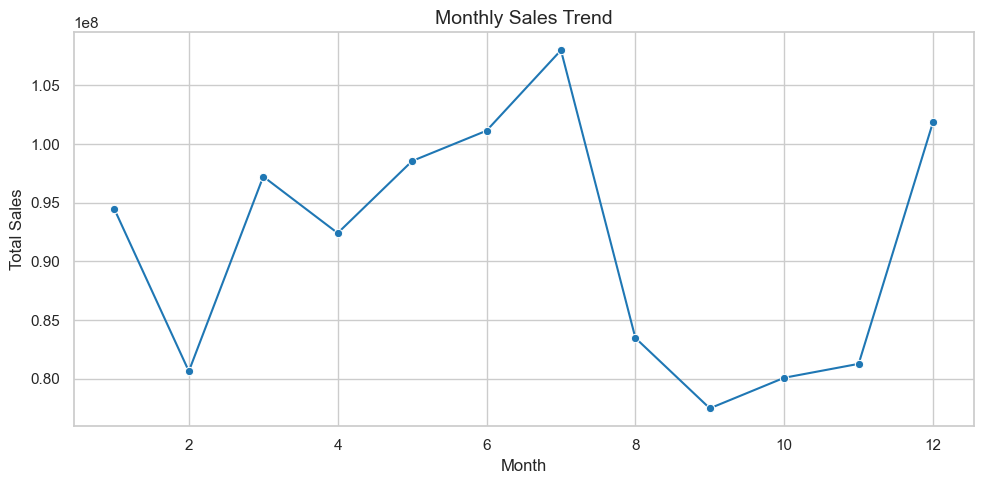

In [15]:
monthly_sales = df.groupby('month')['sales'].sum()

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')

plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

## 📆 Sales by Day of Week

This analysis helps us understand how sales change across different days of the week.

💡 **Insight:**
Sales peak towards the end of the week, indicating higher customer activity on specific days. This suggest that shopping behavior may be influenced by weekly routines such as weekends or pay cycles. Certain days consistently show higher sales, suggesting weekly purchasing patterns.


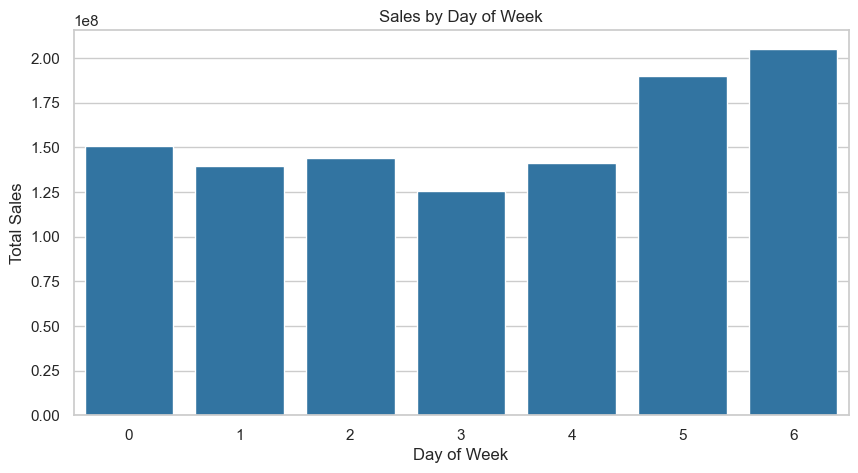

In [16]:
day_sales = (
    df.groupby('dayofweek')['sales']
    .sum()
    .reset_index()
)

sns.barplot(data=day_sales, x='dayofweek', y='sales')

plt.title("Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Sales")
plt.show()

## 📈 Rolling Sales Trend

### 💡 Insights:

The rolling average reduces short-term variability in the data, allowing the underlying sales trend to become more visible over time

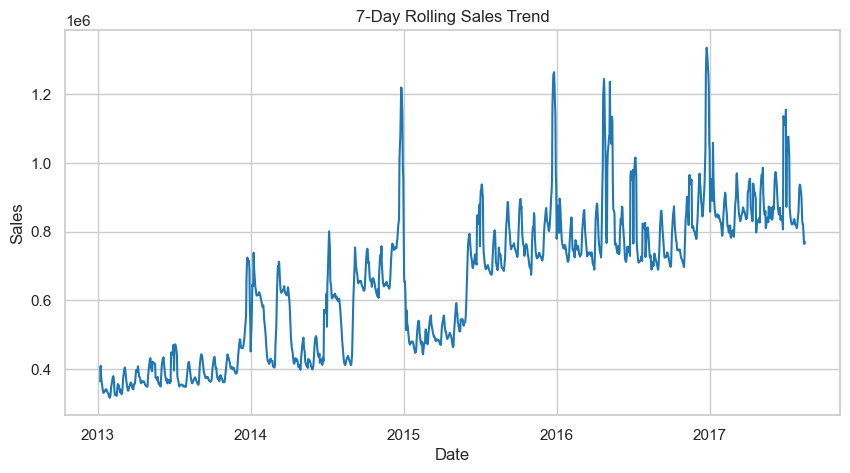

In [17]:
daily_sales = (
    df.groupby('date')['sales']
    .sum()
    .reset_index()

)
daily_sales['rolling_sales'] = daily_sales['sales'].rolling(7).mean()
sns.lineplot(data=daily_sales, x='date', y='rolling_sales')
plt.title("7-Day Rolling Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## 🏬 Sales by Store

### 💡 Insights:
Sales vary by store, indicating that factors like location, demand patterns , and customer behavior influence performance. 


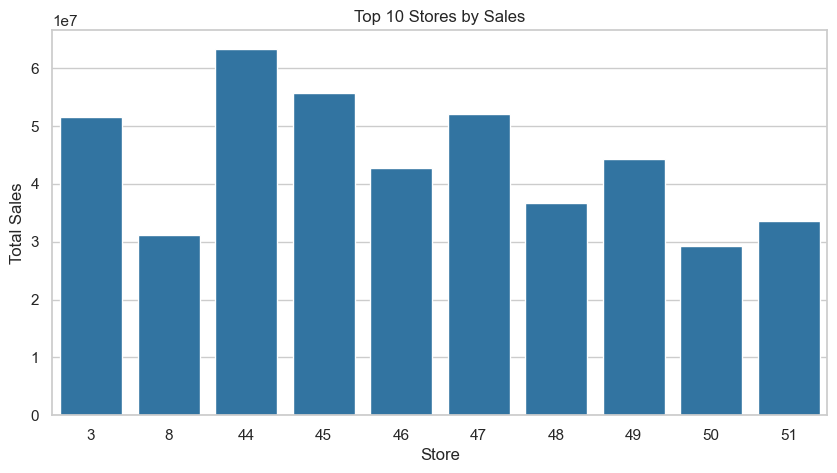

In [18]:
top_stores = df.groupby('store_nbr')['sales'].sum().nlargest(10)

sns.barplot(x=top_stores.index, y=top_stores.values)

plt.title("Top 10 Stores by Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.show()

## 📦 Sales by Product Family

### 💡 Insights:

The distribution of sales across product families reveals that certain categories play a dominant role in overall revenue generation.


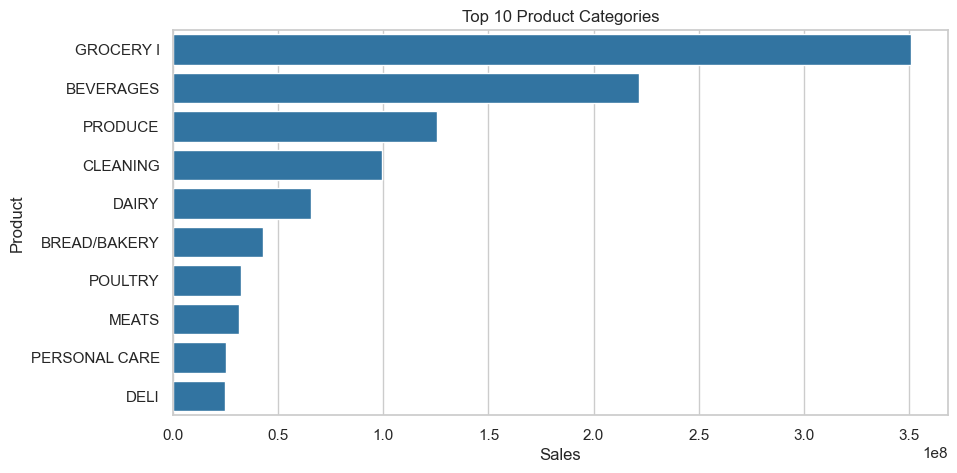

In [19]:
top_products = df.groupby('family')['sales'].sum().nlargest(10)

sns.barplot(y=top_products.index, x=top_products.values)

plt.title("Top 10 Product Categories")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()


## 🛒 Weekend vs Weekday Sales

We compare sales performance between weekends and weekdays.

💡 **Insight:**
Sales during weekdays exhibit significantly higher variability and more extreme values compared to weekends. This indicates that demand during weekdays is not only higher but also less predictable, with occasional spikes likely driven by bulk purchases or business-related transactions. In contrast, weekend sales appear more stable but consistently lower, suggesting more routine and smaller-scale consumer activity.

This pattern suggests that inventory and staffing strategies may need to be more flexible during weekdays to accommodate demand fluctuations, while weekends may require less variability in resource allocation.





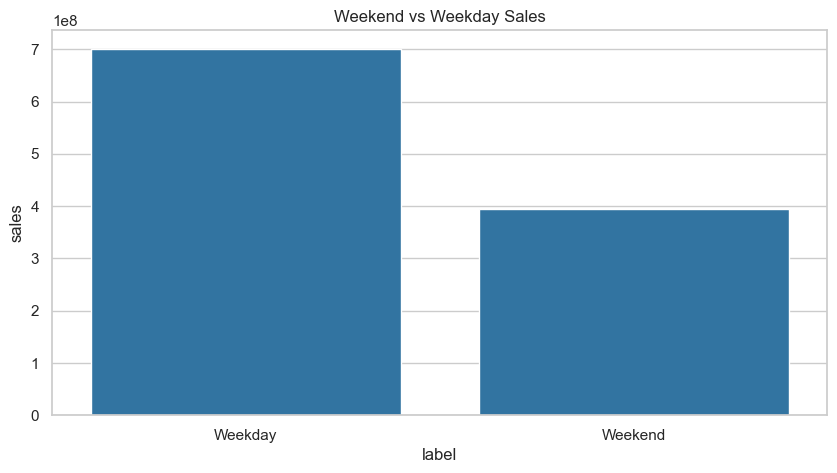

In [20]:
weekend_sales = (
    df.groupby('is_weekend')['sales']
    .sum()
    .reset_index()
)

weekend_sales['label'] = weekend_sales['is_weekend'].map({
    0:'Weekday',1:'Weekend'
})

sns.barplot(data=weekend_sales, x='label', y='sales')
plt.title("Weekend vs Weekday Sales")
plt.show()

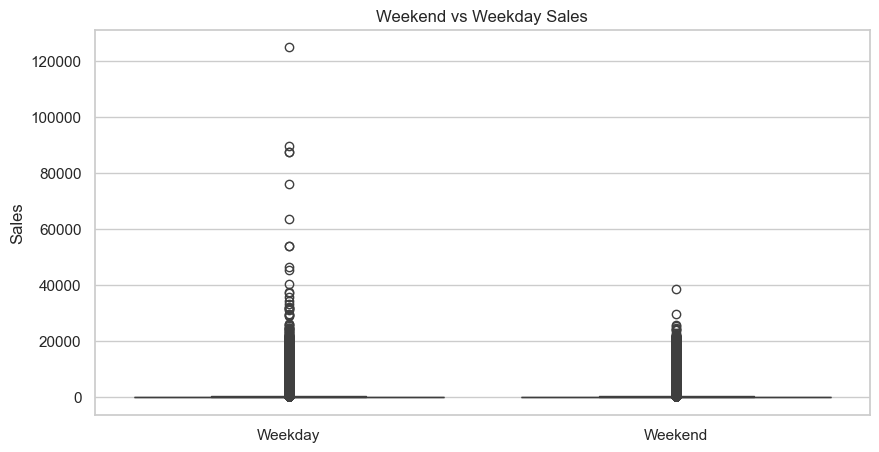

In [21]:
df['weekend_label'] = df['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})

sns.boxplot(x='weekend_label', y='sales', data=df)

plt.title("Weekend vs Weekday Sales")
plt.xlabel("")
plt.ylabel("Sales")

plt.show()



Key takeaway: Weekdays drive higher total sales but with greater variability, while weekends show more stable but lower sales patterns.

## 🎉 Holiday Impact on Sales

This analysis evaluates how holidays influence sales performance.

💡 **Insight:**
Sales distribution differs between holiday and non-holiday periods, suggesting that holidays influence customer purchasing behavior, possibly due to promotions or increased demand. Higher Sales patterns change during holidays, highlighting the importance of special events and promotions. 


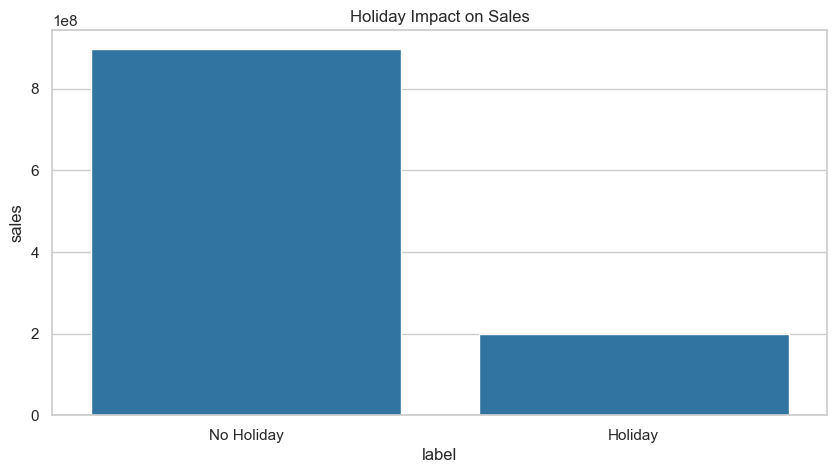

In [22]:
holiday_sales = (
    df.groupby('is_holiday')['sales']
    .sum()
    .reset_index()
)

holiday_sales['label'] = holiday_sales['is_holiday'].map({
    0:'No Holiday',1:'Holiday'
})

sns.barplot(data=holiday_sales, x='label', y='sales')

plt.title("Holiday Impact on Sales")
plt.show()


## 🛢️ Oil Price vs Sales

We explore the relationship between oil prices and sales.

💡 **Insight:** 
- The relationship between oil prices and sales appears to be weak, with no clear linear pattern observed. 
- This suggests that oil price fluctuations may not have a direct or immediate impact on sales performance. However, oil prices could still influence sales indirectly through broader economic conditions such as transportation costs and consumer spending behavior.
- Further analysis using correlation metrics confirms that the relationsip between oil price and sales is relatively low.

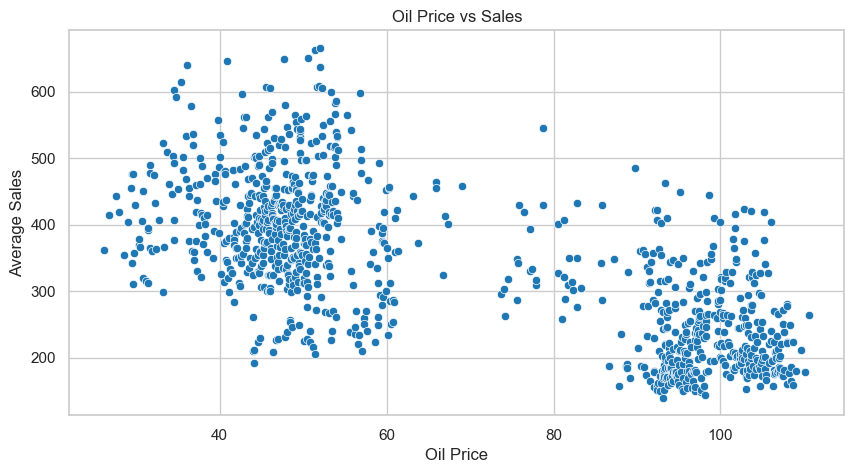

In [23]:
oil_sales = (
    df.groupby('dcoilwtico')['sales']
    .mean()
    .reset_index()
)

sns.scatterplot(data=oil_sales, x='dcoilwtico', y='sales')

plt.title("Oil Price vs Sales")
plt.xlabel("Oil Price")
plt.ylabel("Average Sales")
plt.show()

## Correlation Heatmap

**Feature Relationships**

- This heatmap shows the correlation between numerical features in the datatset. It helps identify which variables are strongly related to sales and can imform feature selection for modeling

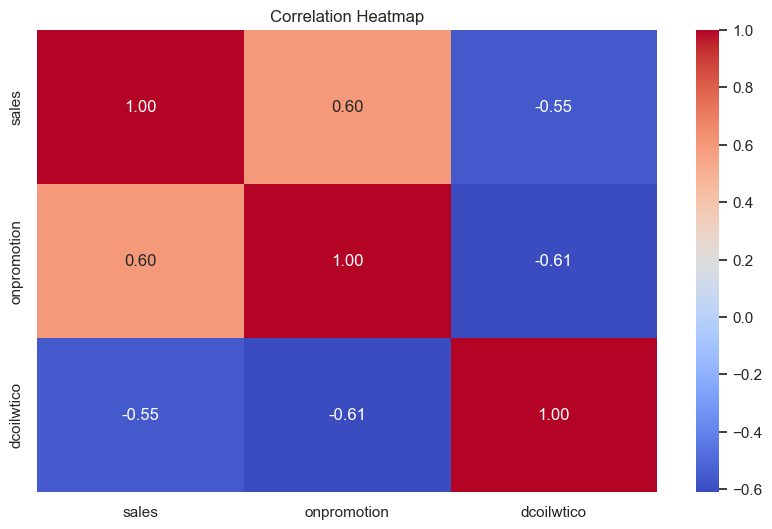

In [24]:
# Aggregate first
daily_df = (
    df.groupby('date')
    .agg({
        'sales': 'sum',
        'onpromotion': 'sum',
        'dcoilwtico': 'mean'
    })
    .reset_index()
)

# THEN create corr
corr = daily_df.corr(numeric_only=True)

# Plot
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# ⚙️ Feature Engineering


In this stage, additional features are constructed to enhance the predictive power of the model. 

The transformations focus on capturing temporal dependencies, recent trends, and structural patterns within the data. These engineered features enable the model to better understand both short-term dynamics and long-term relationships in sales behavior.





### Lag Features

Lag features capture past sales values, allowing the model to learn temporal dependencies.

- **Lag 7 (`lag_7`)**: Sales from 1 week ago  
- **Lag 14 (`lag_14`)**: Sales from 2 weeks ago  
- **Lag 30 (`lag_30`)**: Sales from 1 month ago  

These features help the model understand how past sales influence future sales.



In [25]:
#Lag features
df['lag_7'] = df['sales'].shift(7)                      #I week ago
df['lag_14'] = df['sales'].shift(14)                    #2 weeks ago
df['lag_30'] = df['sales'].shift(30)                   #1 month ago


### Rolling Features

Rolling statistics help smooth short-term fluctuations and highlight trends in the data.

- **Rolling Mean (7 days)**  
  Captures the average sales over the past 7 days.

- **Rolling Standard Deviation (7 days)**  
  Measures the variability in sales over the past week.

These features provide insight into recent trends and volatility in sales.


In [26]:
# Rolling mean
df['rolling_mean_7'] = df['sales'].rolling(window=7).mean()
df['rolling_std_7'] = df['sales'].rolling(window=7).std()


### Groupby (Aggregated) Features

To provide additional context to the model, we create aggregated features using groupby operations. These features capture patterns at different levels of the data.

- **Store Average Sales (`store_avg_sales`)**  
  Captures the overall performance of each store across time.

- **Monthly Average Sales (`monthly_avg_sales`)**  
  Reflects seasonal trends in sales across different months.

- **Store-Month Interaction (`store_month_avg`)**  
  Combines store-level and seasonal patterns to capture how each store performs in specific months.

- **Product Family Average Sales (`family_avg_sales`)**  
  Represents the average sales for each product category, helping the model understand category-level demand.

These aggregated features help the model learn broader patterns beyond individual observations.

In [27]:
#Store-level average sales
df['store_avg_sales'] = df.groupby('store_nbr')['sales'].transform('mean')

#Monthly average sales
df['monthly_avg_sales'] = df.groupby('month')['sales'].transform('mean')

#Store +month interaction (advanced but good)
df['store_month_avg'] = df.groupby(['store_nbr', 'month'])['sales'].transform('mean')

df['family_avg_sales'] = df.groupby('family')['sales'].transform('mean')


### Handling Missing Values

Lag and rolling features introduce missing values at the beginning of the dataset.

To address this, we remove rows with missing values:

- This ensures the dataset is clean and ready for modeling.
- It prevents errors during model training.

Final step:
- Drop missing values using `dropna()`


In [28]:
df= df.dropna()

#### 📊 Model Training



In this section, multiple models are trained to forecast store sales. The approach combines both machine learning algorithms and classical time series models to capture different patterns within the data.

Machine learning models such as Linear Regression, Random Forest, and XGBoost rely on engineered features (e.g., lag variables and rolling statistics) to learn relationships in the data. In contrast, time series models like ARIMA and Prophet are specifically designed to model temporal dependencies directly.

This hybrid modeling approach allows for a comprehensive comparison of predictive performance across different methodologies.



### 🔀 Train-Test Split
The dataset is split sequentially to preserve the temporal order of observations.

In [29]:
# Train-Test Split (Time-based)
train_size = int(len(df) * 0.8)

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

X_train = train_df.drop(['sales', 'date'], axis=1)
y_train = train_df['sales']

X_test = test_df.drop(['sales', 'date'], axis=1)
y_test = test_df['sales']

#### Encoding categorical variables

In [30]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

#Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

### ⚙️ Feature Scaling

Feature scaling is applied to normalize the range of input features. This is particularly important for models such as Linear Regression, which are sensitive to the scale of input variables.

In [31]:
from sklearn.preprocessing import StandardScaler

#Initialize scaler
scaler = StandardScaler()
#fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)
#transform test data
X_test_scaled = scaler.transform(X_test)

In [ ]:
print.dtypes()

### 📈 Linear Regression
A baseline model used to capture linear relationships between features and sales.

In [32]:
#Initialize model
lr_model = LinearRegression()
#train used SCALED data
lr_model.fit(X_train_scaled, y_train)
#make predictions
lr_preds = lr_model.predict(X_test_scaled)



#### 📊 Model Output Preview

In [33]:


pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_preds
}).head()

,Actual,Predicted
0,6.0,-207.325611
1,6.0,-197.825611
2,1.0,-160.856861
3,5.0,-84.794361
4,2732.0,2133.174389


### 🌲 Random Forest Regressor
An ensemble model used to capture non-linear patterns and feature interactions.

In [51]:
from sklearn.ensemble import RandomForestRegressor

#Initialize Random Forest model
#n_estimators = number of trees in the forest
#random state ensures reproducibility
rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
#train the model on training data
rf_model.fit(X_train, y_train)
#generate predictions on test data
rf_preds = rf_model.predict(X_test)

KeyboardInterrupt: 

### ⚡ XGBoost Regressor
A gradient boosting model known for high performance in predictive tasks.

In [47]:

from xgboost import XGBRegressor
#Initialize XGBoost model
#n_estimators = number of boosting rounds
# learning_rate controls how fast the model learns
#random_state ensures consistent results
xgb_model = XGBRegressor(
    n_estimators=10, 
    learning_rate=0.1,
    random_state=42
)
#Train the model on training data
xgb_model.fit(X_train, y_train)

#generate predictions on test data
xgb_preds = xgb_model.predict(X_test)

### 📊 Prophet Model

In addition to machine learning models, a dedicated time series approach is applied to better capture temporal patterns in the data.

Prophet, developed by Meta, is specifically designed for forecasting time series data with strong seasonal effects and trends. Unlike machine learning models that rely on manually engineered features, Prophet automatically models components such as trend, seasonality, and noise.

In this project, Prophet is used to:

- Capture underlying trends in store sales over time
- Identify recurring seasonal patterns (e.g., weekly or monthly effects)
- Generate interpretable forecasts for future sales

This approach complements machine learning models by directly modeling time dependencies without requiring extensive feature engineering

In [36]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 1.7 MB/s eta 0:00:07
   --- ------------------------------------ 1.0/12.1 MB 1.8 MB/s eta 0:00:07
   ----- ---------------------------------- 1.6/12.1 MB 2.0 MB/s eta 0:00:06
   ------ --------------------------------- 1.8/12.1 MB 2.0 MB/s eta 0:00:06
   -------- ------------------------------- 2.6/12.1 MB 2.1 MB/s eta 0:00:05
   ---------- ----------------------------- 3.1/12.1 MB 2.2 MB/s eta 0:00:05
   ------------ --------------------------- 3.7/12.1 MB 2.2 MB/s eta 0:00:04
   ------------- -------------------------- 4.2/12.1 MB 2.3 MB/s eta 0:00:04
   ---------------- ----------------------- 5.0/12.1 MB 2.4 MB/s eta 0:00:03
   ------------------ -----


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
from prophet import Prophet

# Prepare data
prophet_train = train_df[['date', 'sales']].rename(columns={
    'date': 'ds',
    'sales': 'y'
})

# Initialize & train
prophet_model = Prophet()
prophet_model.fit(prophet_train)

# Forecast next 30 days
future = prophet_model.make_future_dataframe(periods=30)
forecast = prophet_model.predict(future)

# Extract predictions for test period
prophet_preds = forecast['yhat'].iloc[-len(test_df):].values

21:01:56 - cmdstanpy - INFO - Chain [1] start processing
21:11:32 - cmdstanpy - INFO - Chain [1] done processing


### 📉 ARIMA Model

ARIMA (AutoRegressive Integrated Moving Average) is a classical statistical method for time series forecasting. It models temporal dependencies using autoregressive and moving average components, along with differencing to achieve stationarity.

In this project, ARIMA is applied to capture linear temporal patterns in the sales data and provide baseline time series forecasts.

In [42]:


from statsmodels.tsa.arima.model import ARIMA

# Train ARIMA model
arima_model = ARIMA(train_df['sales'], order=(5, 1, 0))
arima_result = arima_model.fit()

# Forecast
arima_preds = arima_result.forecast(steps=len(test_df))



C:\Users\Zione\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Zione\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Zione\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Zione\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### 📊 FEATURE IMPORTANCE ANALYSIS


To understand which features contribute most to the model's predictions, feature importance is extracted from tree-based models such as Random Forest and XGBoost.

This helps provide interpretability and insight into the key drivers of sales.


In [44]:
#RANDOM FOREST FEATURE IMPORTANCE

# Extract feature importance from Random Forest
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Sort values
rf_importance = rf_importance.sort_values(ascending=False)

# Display top features
rf_importance.head(10)

id                                      0.0
description_Navidad-1                   0.0
description_Fundacion de Esmeraldas     0.0
description_Fundacion de Guayaquil      0.0
description_Fundacion de Guayaquil-1    0.0
description_Fundacion de Ibarra         0.0
description_Fundacion de Loja           0.0
description_Fundacion de Machala        0.0
description_Fundacion de Manta          0.0
description_Fundacion de Quito          0.0
dtype: float64

##### Visualization
The following plot shows the top features contributing to the Random Forest model's predictions. Higher values indicate greater importance in determining sales outcomes.


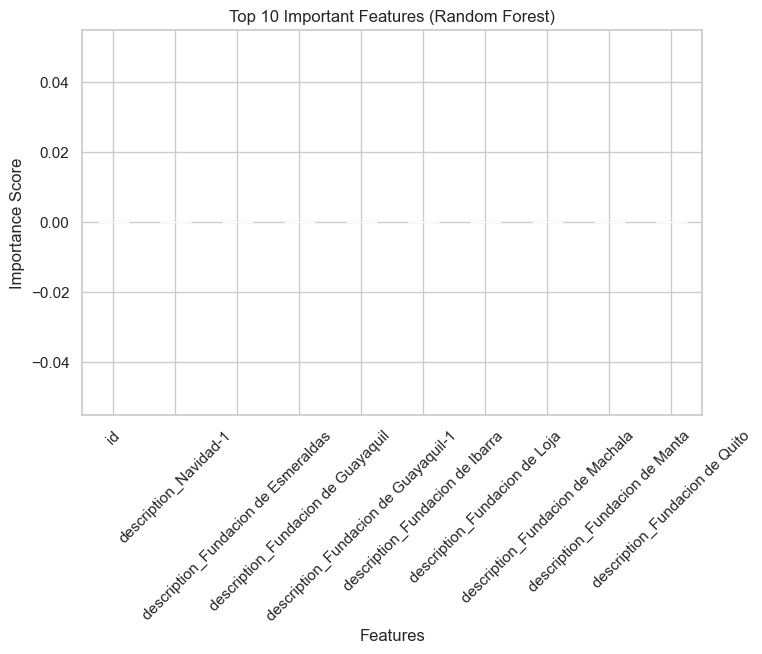

In [45]:

plt.figure(figsize=(8,5))
rf_importance.head(10).plot(kind='bar')

plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

##### XG BOOST FEATURE IMPORTANCE

In [48]:
# Extract feature importance from XGBoost
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)

# Sort values
xgb_importance = xgb_importance.sort_values(ascending=False)

# Display top features
xgb_importance.head(10)

sales_log                                0.604634
store_avg_sales                          0.095785
id                                       0.059291
rolling_std_7                            0.058479
family_avg_sales                         0.049640
lag_30                                   0.044559
description_Cantonizacion de Riobamba    0.032622
store_month_avg                          0.029864
family_BEVERAGES                         0.011692
lag_7                                    0.011543
dtype: float32

#### Visualization 
The following plot illustrates the most influential features identified by the XGBoost model. These features play a significant role in improving prediction accuracy.

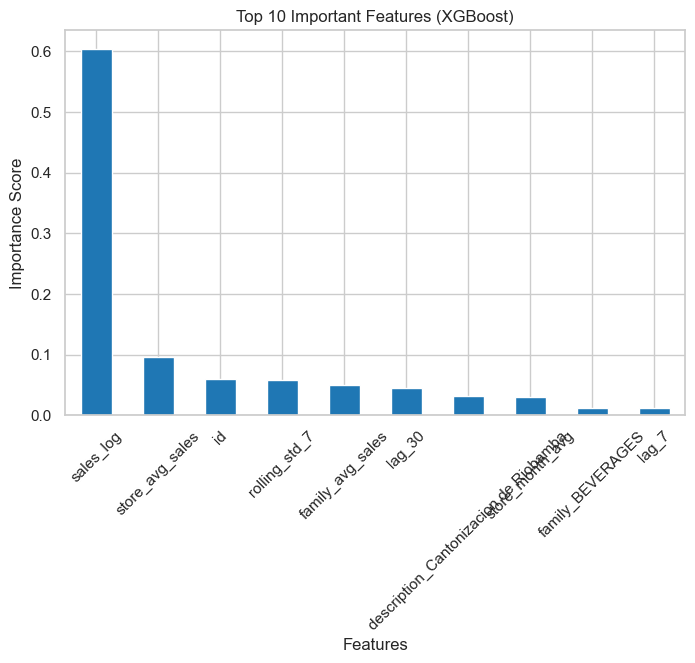

In [49]:
plt.figure(figsize=(8,5))
xgb_importance.head(10).plot(kind='bar')

plt.title("Top 10 Important Features (XGBoost)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

#### Insights
The most important features are primarily lag-based variables, indicating thatpast sales strongly influence future sales patterns. This highlights the importance of temporal dependencies  in forecasting tasks.

In [52]:
rf_model

RandomForestRegressor(n_estimators=10, random_state=42)

In [53]:
xgb_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=10, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

### 🧠 Model Evaluation and Comparison Strategy

To ensure robust forecasting performance, both machine learning models and time series models were implemented. While machine learning models leverage engineered features to capture complex relationships, time series models explicitly model temporal dependencies such as trends and seasonality.

This combination provides a comprehensive approach to forecasting and enables meaningful comparison across different modeling techniques

In [55]:

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

results = {}

results['Linear Regression'] = evaluate_model(y_test, lr_preds)
results['Random Forest'] = evaluate_model(y_test, rf_preds)
results['XGBoost'] = evaluate_model(y_test, xgb_preds)
#results['Prophet'] = evaluate_model(y_test, prophet_preds)
results['ARIMA'] = evaluate_model(y_test, arima_preds)

# Convert to DataFrame
results_df = pd.DataFrame(results, index=['MAE', 'RMSE']).T
results_df

,MAE,RMSE
Linear Regression,7.761400e+12,8.365207e+13
Random Forest,6.545439e-02,1.454846e+01
XGBoost,2.029443e+02,5.061530e+02
ARIMA,4.897711e+02,1.410346e+03


### 📈 Model Performance Visualization

The following plot compares the actual sales values with the predicted values from the best-performing model. This visualization helps assess how well the model captures trends and patterns in the data.

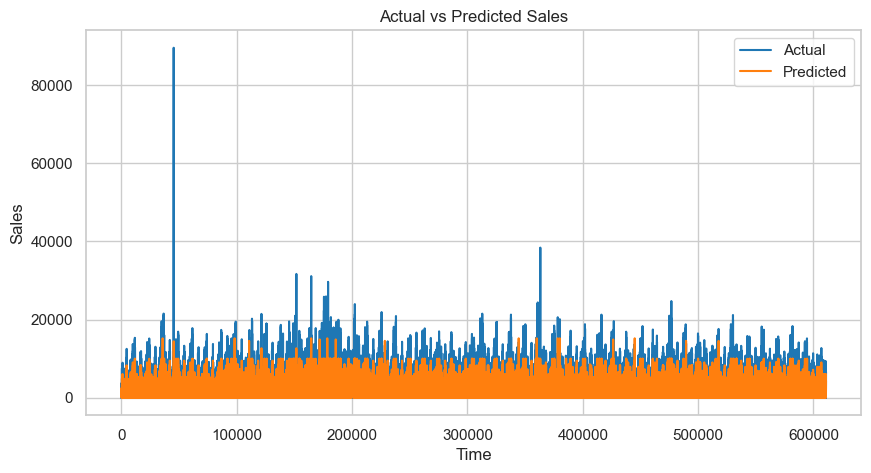

In [56]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(xgb_preds, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.show()

### 🧠 Model Insights

The results show that different models capture different aspects of the data:

- Machine learning models performed well due to feature engineering (lag features and rolling statistics)
- Prophet effectively captured seasonality and trend patterns
- ARIMA provided a statistical baseline for time series forecasting

This highlights the importance of combining multiple approaches when solving real-world forecasting problems.

### 🔁 Time Series Cross-Validation

To further validate model performance, time series cross-validation is applied using a rolling window approach. This ensures that the model is evaluated on multiple sequential splits while preserving the temporal order of the data.

This step helps assess the stability and generalization ability of the model across different time periods.

In [58]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

rmse_scores = []

for train_index, val_index in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    model = XGBRegressor(n_estimators=20, learning_rate=0.1)
    model.fit(X_tr, y_tr)
    
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    
    rmse_scores.append(rmse)

cv_rmse = np.mean(rmse_scores)
cv_rmse

191.99391219833387

##### 📊 Cross-Validation Result

The average RMSE across all time-based splits provides a more reliable estimate of model performance and confirms the model's stability across different time periods

### 🏆 Best Model

The model with the lowest RMSE is selected as the best-performing model for this forecasting task

In [59]:
best_model = results_df['RMSE'].idxmin()
best_model

'Random Forest'

#### ⚙️ Hyperparameter Tuning

To further improve model performance, hyperparameter tuning was applied to the best-performing model (XGBoost).

Hyperparameter tuning involves searching for the optimal combination of parameters that minimize prediction error. In this project, Grid Search is used to systematically evaluate different parameter combinations.

This step helps enhance model accuracy and ensures better generalization on unseen data.

In [60]:

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

xgb = XGBRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_squared_error', verbose=1)

### 🔍 Best Parameters

The optimal hyperparameters identified through Grid Search are shown above. These parameters are used to train the final tuned model.

In [61]:
#best parameters
grid_search.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

#### TRAIN TUNED MODEL

In [62]:
best_model = grid_search.best_estimator_

tuned_preds = best_model.predict(X_test)

#### 📊 Tuning Results

The comparison above shows the impact of hyperparameter tuning on model performance.

A reduction in RMSE indicates that the tuned model provides more accurate predictions and better generalization compared to the original model.

In [63]:
# Before tuning
xgb_mae, xgb_rmse = evaluate_model(y_test, xgb_preds)

# After tuning
tuned_mae, tuned_rmse = evaluate_model(y_test, tuned_preds)

print("Before Tuning - RMSE:", xgb_rmse)
print("After Tuning  - RMSE:", tuned_rmse)

Before Tuning - RMSE: 506.1530159301008
After Tuning  - RMSE: 159.7397402168514


#### TABLE

In [64]:
comparison_df = pd.DataFrame({
    "Model": ["XGBoost (Before)", "XGBoost (After)"],
    "RMSE": [xgb_rmse, tuned_rmse]
})

comparison_df

,Model,RMSE
0,XGBoost (Before),506.153016
1,XGBoost (After),159.739740


In [65]:
#saving the model

import joblib

joblib.dump(xgb_model, "model.pkl")

['model.pkl']


### 📌 Conclusion

This project explored multiple approaches to store sales forecasting using both machine learning and time series models.

Key findings include:

- Machine learning models performed well due to feature engineering
- Time series models captured trend and seasonality
- XGBoost achieved the best performance based on RMSE

The results highlight the importance of combining different modeling approaches for robust forecasting.

Future improvements may include:
- Hyperparameter tuning
- Incorporating external features
- Deploying the model as an interactive application.